# LeetCode #127: Word Ladder

https://leetcode.com/problems/word-ladder/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| DFS (find any path) | Exponential | O(n) | Not guaranteed shortest |
| **BFS (level-by-level)** | **O(n·L²)** | **O(n·L)** | **Optimal — guaranteed shortest path** |

## Understanding the Method

BFS guarantees the shortest path in an unweighted graph.
- At each word, try all 26 × L character substitutions
- If the new word is in the word set, add it to the queue
- Remove visited words from the set to prevent cycles
- Return level count when endWord is found

## Constraints

- `1 <= beginWord.length <= 10`
- `endWord.length == beginWord.length`
- `1 <= wordList.length <= 5000`
- All words consist of lowercase English letters.

## Solutions

### C#

In [ ]:
public class Solution {
    public int LadderLength(string beginWord, string endWord, IList<string> wordList) {
        var wordSet = new HashSet<string>(wordList);
        if (!wordSet.Contains(endWord)) return 0;
        var queue = new Queue<(string, int)>();
        queue.Enqueue((beginWord, 1));
        while (queue.Count > 0) {
            var (word, dist) = queue.Dequeue();
            char[] arr = word.ToCharArray();
            for (int i = 0; i < arr.Length; i++) {
                char orig = arr[i];
                for (char c = 'a'; c <= 'z'; c++) {
                    if (c == orig) continue;
                    arr[i] = c;
                    string next = new string(arr);
                    if (next == endWord) return dist + 1;
                    if (wordSet.Contains(next)) {
                        wordSet.Remove(next);
                        queue.Enqueue((next, dist + 1));
                    }
                    arr[i] = orig;
                }
            }
        }
        return 0;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def ladderLength(self, beginWord: str, endWord: str, wordList: list[str]) -> int:
        word_set = set(wordList)
        if endWord not in word_set:
            return 0
        queue = deque([(beginWord, 1)])
        while queue:
            word, dist = queue.popleft()
            for i in range(len(word)):
                for c in 'abcdefghijklmnopqrstuvwxyz':
                    nw = word[:i] + c + word[i+1:]
                    if nw == endWord:
                        return dist + 1
                    if nw in word_set:
                        word_set.discard(nw)
                        queue.append((nw, dist + 1))
        return 0

### Go

In [ ]:
func ladderLength(beginWord string, endWord string, wordList []string) int {
    wordSet := map[string]bool{}
    for _, w := range wordList { wordSet[w] = true }
    if !wordSet[endWord] { return 0 }
    type Item struct{ word string; dist int }
    queue := []Item{{beginWord, 1}}
    for len(queue) > 0 {
        item := queue[0]; queue = queue[1:]
        bs := []byte(item.word)
        for i := 0; i < len(bs); i++ {
            orig := bs[i]
            for c := byte('a'); c <= 'z'; c++ {
                if c == orig { continue }
                bs[i] = c
                nw := string(bs)
                if nw == endWord { return item.dist + 1 }
                if wordSet[nw] {
                    delete(wordSet, nw)
                    queue = append(queue, Item{nw, item.dist + 1})
                }
                bs[i] = orig
            }
        }
    }
    return 0
}

### Rust

In [ ]:
use std::collections::{HashSet, VecDeque};

impl Solution {
    pub fn ladder_length(begin_word: String, end_word: String, word_list: Vec<String>) -> i32 {
        let mut word_set: HashSet<String> = word_list.into_iter().collect();
        if !word_set.contains(&end_word) { return 0; }
        let mut queue: VecDeque<(Vec<u8>, i32)> = VecDeque::new();
        queue.push_back((begin_word.into_bytes(), 1));
        while let Some((word, dist)) = queue.pop_front() {
            let mut bs = word.clone();
            for i in 0..bs.len() {
                let orig = bs[i];
                for c in b'a'..=b'z' {
                    if c == orig { continue; }
                    bs[i] = c;
                    let nw = String::from_utf8(bs.clone()).unwrap();
                    if nw == end_word { return dist + 1; }
                    if word_set.contains(&nw) {
                        word_set.remove(&nw);
                        queue.push_back((bs.clone(), dist + 1));
                    }
                    bs[i] = orig;
                }
            }
        }
        0
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `beginWord = "hit"`, `endWord = "cog"`, `wordList = ["hot","dot","dog","lot","log","cog"]`  
BFS level by level: Level 1: hit. Level 2: hot. Level 3: dot, lot. Level 4: dog, log. Level 5: cog found! Return 5.  
WHY tricky: BFS guarantees shortest path in unweighted graph. Count = words in sequence (including start), not transformations. LaTeX: $\text{dist} = 5$.

### 2. Slightly Complex -- Unreachable Target
**Input:** `beginWord = "hit"`, `endWord = "cog"`, `wordList = ["hot","dot","dog","lot","log"]`  
"cog" not in word list. Return 0. Even full BFS cannot produce a word outside the list.  
WHY tricky: Early termination saves traversal. Interview follow-up: what if endWord exists but is in a disconnected component? LaTeX: $\text{endWord} \notin S \Rightarrow 0$.

### 3. Edge Case: Time Factor
**Input:** $5000$ words of length $10$, densely connected  
Per word: $10 \times 26 = 260$ substitutions, each with $O(L)$ string creation. Total: $O(n \cdot L^2) = 5000 \times 260 \times 10 = 13{,}000{,}000$. Tight but feasible.  
WHY tricky: String creation in inner loop is $O(L)$, making total $O(n \cdot L^2)$. Optimization: wildcard patterns to group neighbors. LaTeX: $T = O(n \cdot L \cdot 26 \cdot L) = O(n \cdot L^2)$.

### 4. Edge Case: Space Factor
**Input:** $5000$ words of length $10$  
HashSet stores all words: $O(n \cdot L) = 50{,}000$ chars. BFS queue holds up to $O(n)$ entries. Removing visited words from set saves a separate visited structure.  
WHY tricky: Removing from set instead of marking visited saves space. Each word processed at most once. LaTeX: $S = O(n \cdot L)$.

### 5. Almost-Impossible but Plausible
**Input:** `beginWord = "aaaaaaaaaa"`, `endWord = "zzzzzzzzzz"`, $5000$ words forming one long chain  
Path visits all 5000 words $+ 1 = 5001$ steps. BFS queue has 1 word per level (no branching). Each of 5000 levels does 250 substitutions. Total: $5000 \times 250 \times 10 = 12.5M$ ops.  
WHY tricky: Maximum path length with minimum branching. Tests BFS at max depth with small queue. LaTeX: $\text{answer} = n + 1 = 5001$.

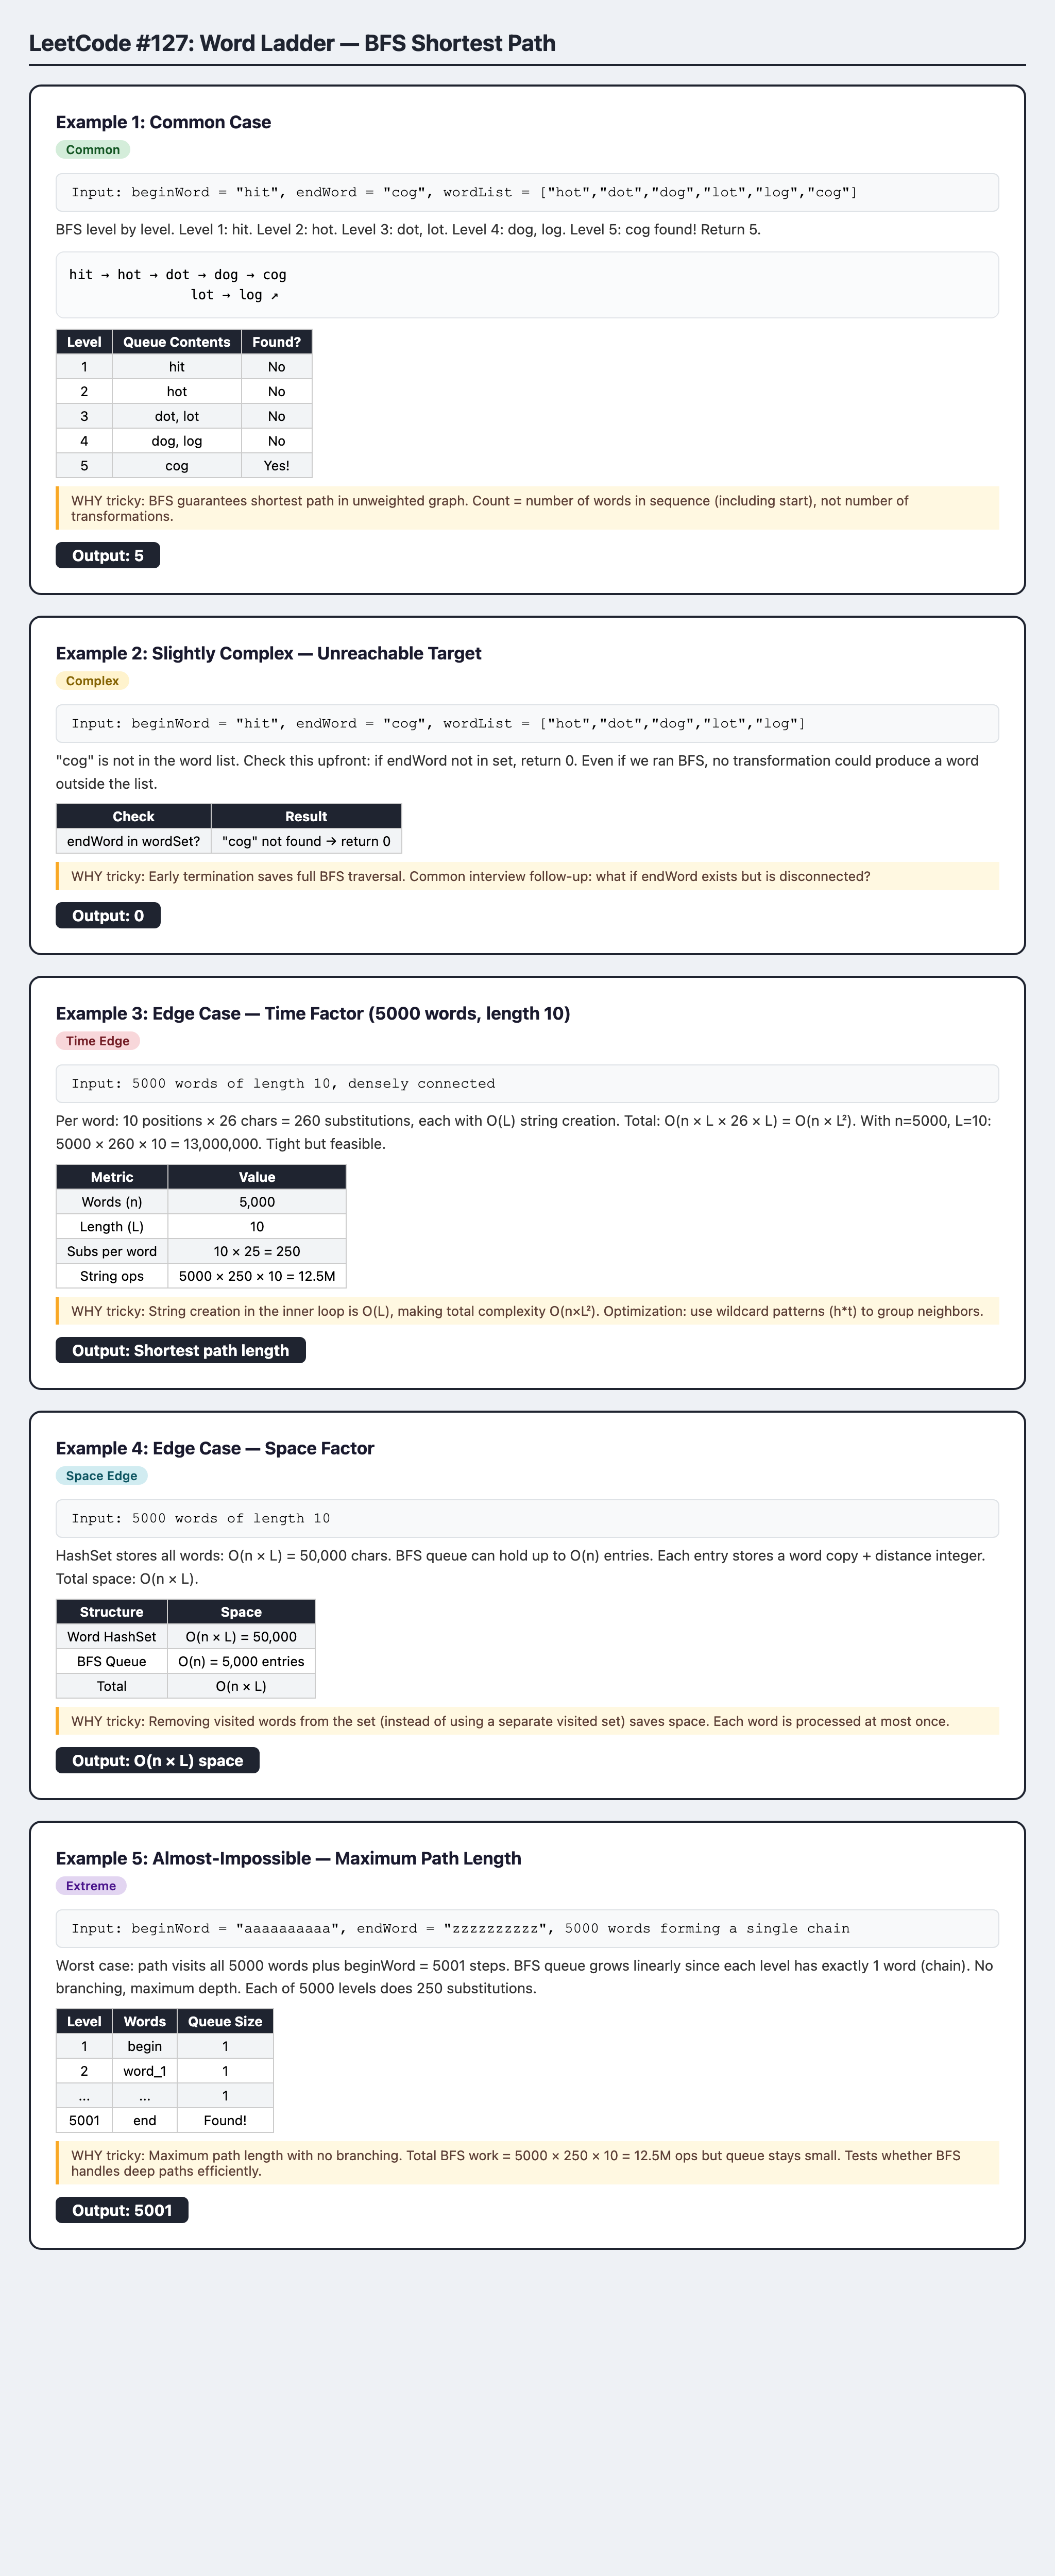